In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [10]:
num_samples_per_class = 1000
neg_samples = np.random.multivariate_normal(
    mean = [0, 3],
    cov = [[1, 0.5], [0.5, 1]],
    size = num_samples_per_class)

pos_samples = np.random.multivariate_normal(
    mean = [3, 0],
    cov = [[1, 0.5], [0.5, 1]],
    size = num_samples_per_class)

inputs = np.vstack((neg_samples, pos_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

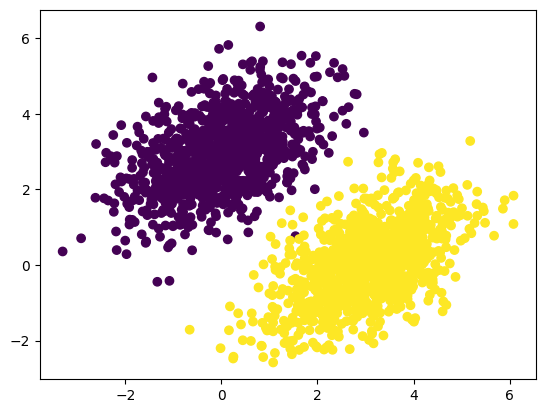

In [11]:
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [18]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim)))

def model(inputs):
    return tf.matmul(inputs, W) + b

def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

learning_rate = 0.1

def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [19]:
for step in range(40):
    loss = training_step(inputs, targets)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 4.0497
Loss at step 1: 0.3120
Loss at step 2: 0.1403
Loss at step 3: 0.1106
Loss at step 4: 0.1005
Loss at step 5: 0.0936
Loss at step 6: 0.0876
Loss at step 7: 0.0822
Loss at step 8: 0.0772
Loss at step 9: 0.0727
Loss at step 10: 0.0686
Loss at step 11: 0.0648
Loss at step 12: 0.0614
Loss at step 13: 0.0582
Loss at step 14: 0.0554
Loss at step 15: 0.0528
Loss at step 16: 0.0504
Loss at step 17: 0.0482
Loss at step 18: 0.0462
Loss at step 19: 0.0444
Loss at step 20: 0.0428
Loss at step 21: 0.0413
Loss at step 22: 0.0399
Loss at step 23: 0.0386
Loss at step 24: 0.0375
Loss at step 25: 0.0364
Loss at step 26: 0.0355
Loss at step 27: 0.0346
Loss at step 28: 0.0338
Loss at step 29: 0.0331
Loss at step 30: 0.0324
Loss at step 31: 0.0318
Loss at step 32: 0.0313
Loss at step 33: 0.0308
Loss at step 34: 0.0303
Loss at step 35: 0.0299
Loss at step 36: 0.0295
Loss at step 37: 0.0292
Loss at step 38: 0.0289
Loss at step 39: 0.0286


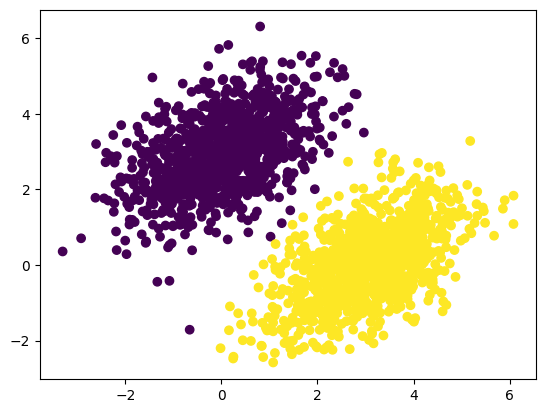

In [22]:
predictions = model(inputs)
plt.show()
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0]>0.5)


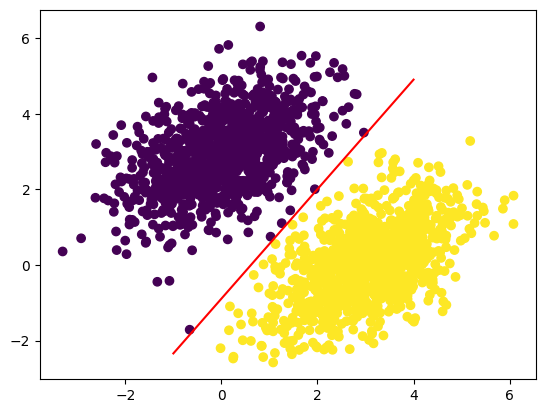

In [23]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] *x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0]>0.5)
